In [1]:
import torch
import matplotlib.pyplot as plt

Data shape: torch.Size([2000, 3])


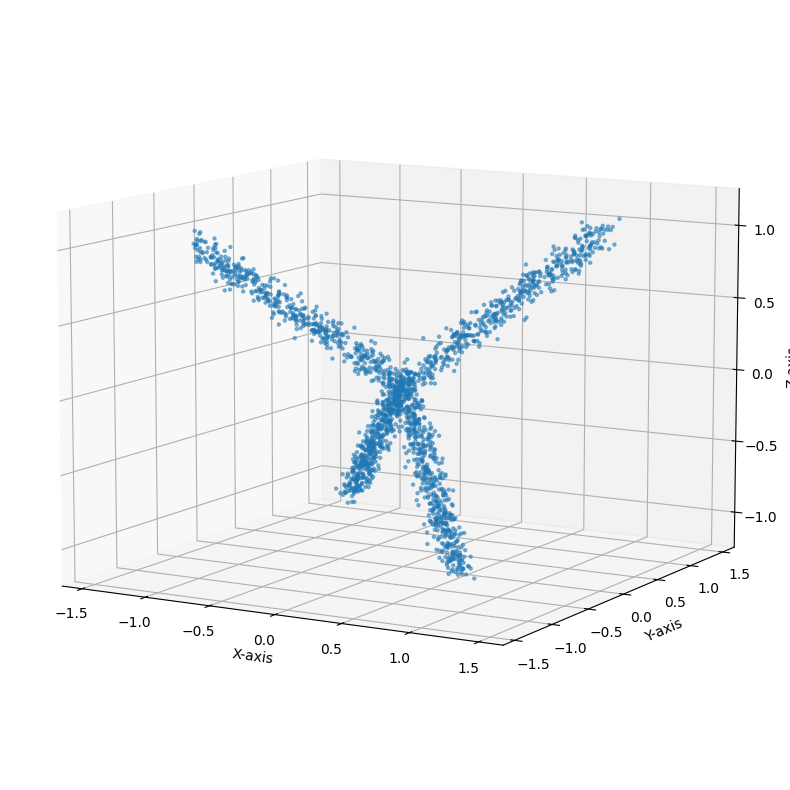

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
sigma = 0.05
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += sigma * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)
print("Data shape:", data.shape)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.show()

In [3]:
from sklearn.decomposition import FastICA
from sklearn.cluster import KMeans

def ica_cluster_covariances_torch(data, n_components, n_clusters, abs=False):
    """
    data: (N, d) torch tensor
    Returns:
      cluster_covs: list of (d, d) torch tensors, one per cluster in original space
      labels: (N,) cluster assignments
    """

    # 1) FastICA: get sources
    ica = FastICA(n_components=n_components, whiten="unit-variance", random_state=0, max_iter=500)
    sources_np = ica.fit_transform(data.numpy())      # (N, k) sources
    print(sources_np)
    A = ica.mixing_                              # (d, k) mixing matrix

    # 2) Classify by finding a k-sparse direction in source space, take absolute values, then k-means
    W = torch.from_numpy(ica.components_) # (k, d) unmixing matrix
    sources_t = torch.from_numpy(sources_np) # (N, k)
    sparse_dir = W[0]  # (d,) take first row of W
    print("sparse_dir:", sparse_dir)
    projections = sources_t @ sparse_dir             # (N,)
    if abs:
        projections = torch.abs(projections)                # (N,)
    projections_np = projections.cpu().numpy().reshape(-1, 1)
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(projections_np)
    labels = torch.from_numpy(kmeans.labels_)  # (N,)    

    # 3) For each cluster, compute covariance in original space
    data_t = data.float()  # (N, d)
    cluster_means = []
    cluster_covs = []

    for c in range(n_clusters):
        idx = (labels == c)
        if idx.sum() < 2:
            # degenerate cluster: fallback to tiny isotropic covariance
            d = data_t.shape[1]
            mean_c = torch.zeros(1, d)
            cov_c = 1e-6 * torch.eye(d)
        else:
            Xc = data_t[idx]                                # (Nc, d)
            mean_c = Xc.mean(dim=0, keepdim=True)
            Xc = Xc - mean_c
            Nc = Xc.shape[0]
            cov_c = (Xc.T @ Xc) / (Nc - 1)                  # (d, d)
        cluster_means.append(mean_c)
        cluster_covs.append(cov_c)

    return cluster_means, cluster_covs, labels

def kmeans_cluster_covariances_torch(data, n_clusters):
    """
    data: (N, d) torch tensor
    Returns:
      cluster_covs: list of (d, d) torch tensors, one per cluster in original space
      labels: (N,) cluster assignments
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(data.numpy())
    labels = torch.from_numpy(kmeans.labels_)  # (N,)    
    data_t = data.float()  # (N, d)
    cluster_means = []
    cluster_covs = []

    for c in range(n_clusters):
        idx = (labels == c)
        if idx.sum() < 2:
            # degenerate cluster: fallback to tiny isotropic covariance
            d = data_t.shape[1]
            mean_c = torch.zeros(1, d)
            cov_c = 1e-6 * torch.eye(d)
        else:
            Xc = data_t[idx]                                # (Nc, d)
            mean_c = Xc.mean(dim=0, keepdim=True)
            Xc = Xc - mean_c
            Nc = Xc.shape[0]
            cov_c = (Xc.T @ Xc) / (Nc - 1)                  # (d, d)
        cluster_means.append(mean_c)
        cluster_covs.append(cov_c)

    return cluster_means, cluster_covs, labels

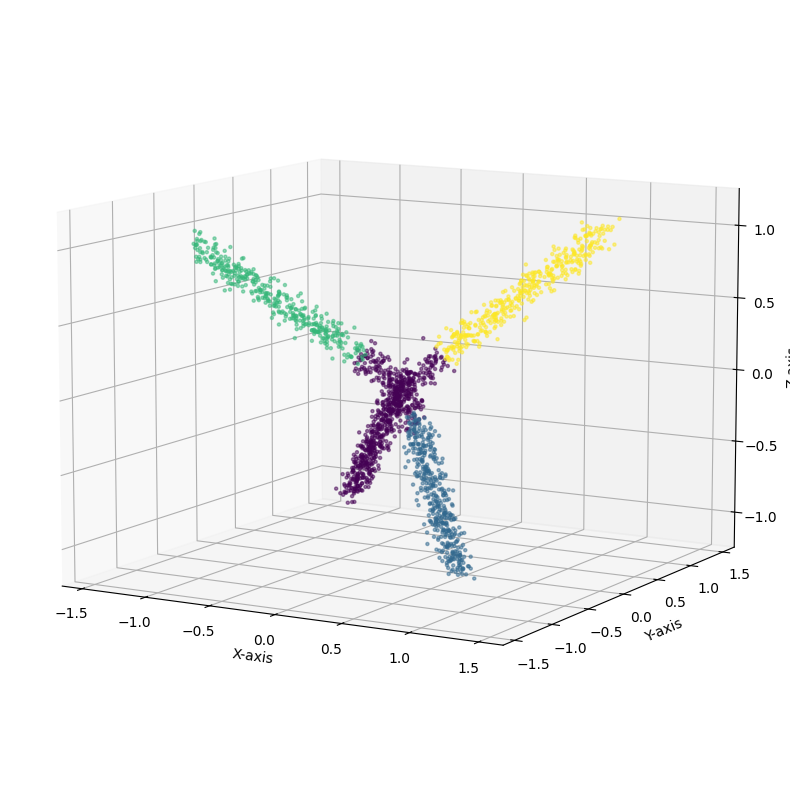

In [4]:
cluster_means, cluster_covs, labels = kmeans_cluster_covariances_torch(data, n_clusters=4)

# plot data colored by cluster assignments
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=labels, s=5, alpha=0.5, cmap='viridis')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.show()